# Experiment 8: Gradient Descent for Function Minimization

**Objective:** To implement the gradient descent algorithm to find minima of multivariable functions.

---

## What is Gradient Descent?

Imagine you are standing on a hilly terrain and you want to reach the lowest point (valley). You look around, find the direction that goes downhill the fastest, and take a small step in that direction. You keep repeating this until you reach the bottom.

That is exactly what Gradient Descent does mathematically:

- The **hill** is your cost/loss function f(x)
- The **direction downhill** is the negative of the gradient (derivative)
- The **step size** is called the **learning rate**

**Update Rule:**

```
x_new = x_old - learning_rate * gradient(f at x_old)
```

---

## Key Terms

| Term | Meaning |
|---|---|
| Gradient | Slope / rate of change of the function |
| Learning Rate | How big a step we take each iteration |
| Iteration | One update of parameters |
| Convergence | When the algorithm reaches (or is very close to) the minimum |
| Cost Function | The function we want to minimize |

---

In [2]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


---
## Example 1: Gradient Descent on a Simple Quadratic Function

**Function:** f(x) = x^2

**Gradient:** f'(x) = 2x

The minimum is at x = 0, where f(0) = 0.

We start at some random point and take steps toward the minimum using:
```
x = x - learning_rate * 2x
```

Final x      : 0.009904
Final f(x)   : 0.000098
True minimum : x = 0, f(x) = 0


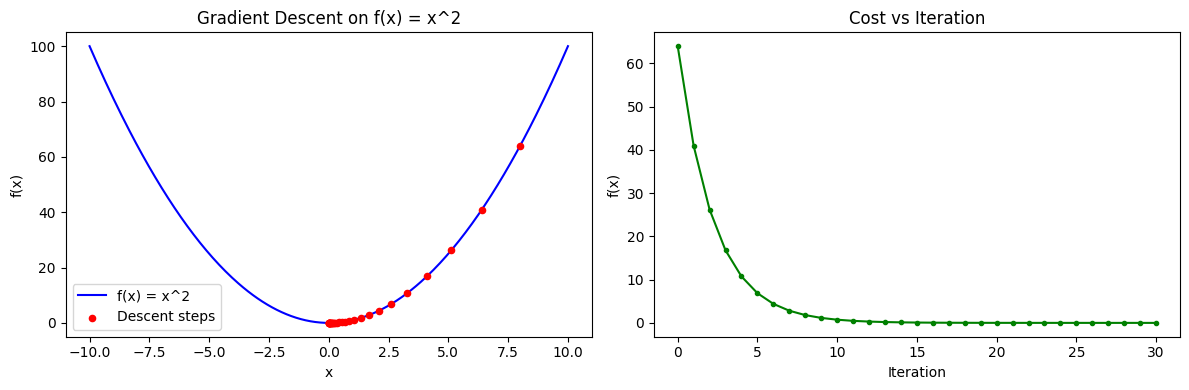

In [3]:
# Example 1: Gradient Descent on f(x) = x^2

def f(x):
    return x ** 2

def gradient_f(x):
    return 2 * x   # derivative of x^2

# Starting point
x = 8.0
learning_rate = 0.1
iterations = 30

history_x = [x]
history_f = [f(x)]

for i in range(iterations):
    grad = gradient_f(x)
    x = x - learning_rate * grad      # gradient descent update
    history_x.append(x)
    history_f.append(f(x))

print(f"Final x      : {x:.6f}")
print(f"Final f(x)   : {f(x):.6f}")
print(f"True minimum : x = 0, f(x) = 0")

# Plot the convergence
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
x_range = np.linspace(-10, 10, 300)
plt.plot(x_range, x_range**2, label='f(x) = x^2', color='blue')
plt.scatter(history_x, [v**2 for v in history_x], color='red', s=20, zorder=5, label='Descent steps')
plt.title('Gradient Descent on f(x) = x^2')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_f, color='green', marker='o', markersize=3)
plt.title('Cost vs Iteration')
plt.xlabel('Iteration')
plt.ylabel('f(x)')

plt.tight_layout()
plt.show()

---
## Example 2: Effect of Learning Rate

The learning rate controls how big each step is.

- **Too small:** Converges very slowly (many iterations needed)
- **Too large:** Overshoots and may diverge
- **Just right:** Converges smoothly and quickly

We compare three learning rates on f(x) = x^2.

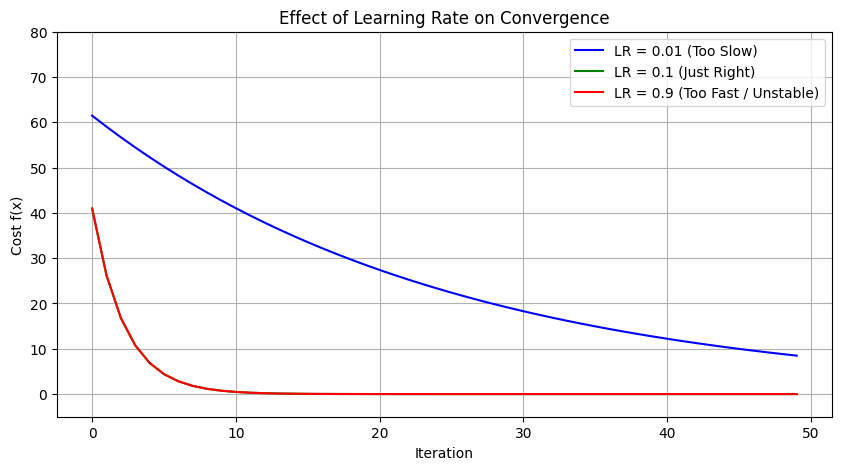

Observation:
- LR = 0.01 converges but takes many steps.
- LR = 0.1 converges smoothly and efficiently.
- LR = 0.9 may oscillate or become unstable.


In [5]:
# Example 2: Effect of Learning Rate on f(x) = x^2

def run_gradient_descent(start_x, lr, iterations=50):
    x = start_x
    cost_history = []
    for _ in range(iterations):
        x = x - lr * 2 * x
        cost_history.append(x**2)
    return cost_history

start = 8.0
learning_rates = [0.01, 0.1, 0.9]
colors = ['blue', 'green', 'red']
labels = ['LR = 0.01 (Too Slow)', 'LR = 0.1 (Just Right)', 'LR = 0.9 (Too Fast / Unstable)']

plt.figure(figsize=(10, 5))
for lr, color, label in zip(learning_rates, colors, labels):
    history = run_gradient_descent(start, lr, iterations=50)
    plt.plot(history, color=color, label=label)

plt.title('Effect of Learning Rate on Convergence')
plt.xlabel('Iteration')
plt.ylabel('Cost f(x)')
plt.ylim(-5, 80)
plt.legend()
plt.grid(True)
plt.show()

print("Observation:")
print("- LR = 0.01 converges but takes many steps.")
print("- LR = 0.1 converges smoothly and efficiently.")
print("- LR = 0.9 may oscillate or become unstable.")

---
## Example 3: Gradient Descent on a Shifted Parabola

**Function:** f(x) = (x - 3)^2 + 5

**Gradient:** f'(x) = 2(x - 3)

The minimum is at x = 3, where f(3) = 5.

This shows gradient descent works for any parabola, not just one centered at zero.

In [ ]:
# Example 3: f(x) = (x - 3)^2 + 5

def f3(x):
    return (x - 3)**2 + 5

def grad_f3(x):
    return 2 * (x - 3)

x = -4.0
lr = 0.1
iterations = 50

path_x = [x]
path_y = [f3(x)]

for _ in range(iterations):
    x = x - lr * grad_f3(x)
    path_x.append(x)
    path_y.append(f3(x))

print(f"Final x      : {x:.6f}  (Expected: 3.0)")
print(f"Final f(x)   : {f3(x):.6f}  (Expected: 5.0)")

x_range = np.linspace(-6, 12, 300)
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(x_range, f3(x_range), 'b-', label='f(x) = (x-3)^2 + 5')
plt.plot(path_x, path_y, 'ro-', markersize=4, label='Descent path')
plt.scatter([3], [5], color='gold', s=150, zorder=6, label='True Minimum (3, 5)')
plt.title('Gradient Descent on Shifted Parabola')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(path_y, 'g-o', markersize=3)
plt.title('Cost vs Iteration')
plt.xlabel('Iteration')
plt.ylabel('f(x)')

plt.tight_layout()
plt.show()

---
## Example 4: Gradient Descent with Two Variables (2D)

**Function:** f(x, y) = x^2 + y^2

**Gradients:**
- Partial derivative w.r.t x: df/dx = 2x
- Partial derivative w.r.t y: df/dy = 2y

The minimum is at (x, y) = (0, 0), where f = 0.

In 2D, gradient descent updates both parameters simultaneously.

In [ ]:
# Example 4: Gradient Descent on f(x, y) = x^2 + y^2

def f4(x, y):
    return x**2 + y**2

def grad_f4(x, y):
    df_dx = 2 * x
    df_dy = 2 * y
    return df_dx, df_dy

# Starting point
x, y = 4.0, 3.0
lr = 0.1
iterations = 40

path_x = [x]
path_y = [y]
cost_history = [f4(x, y)]

for _ in range(iterations):
    gx, gy = grad_f4(x, y)
    x = x - lr * gx
    y = y - lr * gy
    path_x.append(x)
    path_y.append(y)
    cost_history.append(f4(x, y))

print(f"Final x      : {x:.6f}  (Expected: 0.0)")
print(f"Final y      : {y:.6f}  (Expected: 0.0)")
print(f"Final f(x,y) : {f4(x, y):.6f}  (Expected: 0.0)")

# Contour plot
x_range = np.linspace(-5, 5, 200)
y_range = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(x_range, y_range)
Z = X**2 + Y**2

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.contourf(X, Y, Z, levels=30, cmap='viridis')
plt.colorbar(label='f(x, y)')
plt.plot(path_x, path_y, 'r-o', markersize=4, label='Descent path')
plt.scatter([0], [0], color='yellow', s=150, zorder=6, label='Minimum (0,0)')
plt.title('2D Gradient Descent Contour')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cost_history, 'g-o', markersize=3)
plt.title('Cost vs Iteration')
plt.xlabel('Iteration')
plt.ylabel('f(x, y)')

plt.tight_layout()
plt.show()

---
## Example 5: Linear Regression Using Gradient Descent

This is the most practical use of gradient descent in Machine Learning.

We want to fit a line  y = mx + c  to a set of data points.

**Cost Function (Mean Squared Error):**
```
MSE = (1/N) * sum( (y_pred - y_actual)^2 )
```

**Gradients:**
```
dMSE/dm = (2/N) * sum( (y_pred - y_actual) * x )
dMSE/dc = (2/N) * sum( (y_pred - y_actual) )
```

Gradient descent updates m and c step by step to reduce the error.

In [ ]:
# Example 5: Linear Regression using Gradient Descent

np.random.seed(42)

# Generate synthetic data: true relationship is y = 3x + 7
X_data = np.linspace(0, 10, 50)
Y_data = 3 * X_data + 7 + np.random.randn(50) * 2

# Initialize parameters randomly
m = 0.0   # slope
c = 0.0   # intercept
lr = 0.001
iterations = 1000
N = len(X_data)

cost_history = []

for i in range(iterations):
    y_pred = m * X_data + c
    error = y_pred - Y_data

    # Compute cost
    cost = np.mean(error**2)
    cost_history.append(cost)

    # Compute gradients
    dm = (2 / N) * np.sum(error * X_data)
    dc = (2 / N) * np.sum(error)

    # Update parameters
    m = m - lr * dm
    c = c - lr * dc

print(f"Learned slope (m)     : {m:.4f}  (True: 3.0)")
print(f"Learned intercept (c) : {c:.4f}  (True: 7.0)")
print(f"Final MSE Cost        : {cost_history[-1]:.4f}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(X_data, Y_data, color='blue', s=20, label='Data points')
plt.plot(X_data, m * X_data + c, color='red', linewidth=2, label=f'Fitted line: y = {m:.2f}x + {c:.2f}')
plt.title('Linear Regression via Gradient Descent')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cost_history, color='orange')
plt.title('MSE Cost vs Iteration')
plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error')

plt.tight_layout()
plt.show()

---
# Exercise Questions

Try solving these on your own. Each question builds on what you have learned above.

---

### Question 1
Apply gradient descent to minimize the function:

f(x) = (x + 5)^2 - 10

Start at x = 10, use a learning rate of 0.1, and run for 50 iterations.
Plot the descent path on the curve and also plot the cost vs iteration graph.
What is the minimum value of f(x) and at what x is it achieved?

---

### Question 2
Experiment with different learning rates (0.001, 0.3, 1.0, 1.5) on the function:

f(x) = x^2

Start all runs at x = 6. Run for 30 iterations each.
Plot all cost curves on the same graph.
What happens when the learning rate is greater than 1? Explain your observation.

---

### Question 3
Apply gradient descent to minimize the 2D function:

f(x, y) = (x - 2)^2 + (y + 3)^2

Start at (x, y) = (8, 8), use learning rate 0.1, and run for 60 iterations.
Plot the contour map with the descent path.
What are the expected values of x and y at the minimum?

---

### Question 4
Implement gradient descent with an early stopping condition.
Stop the algorithm when the change in cost between two consecutive iterations is less than 0.0001.

Apply this to minimize f(x) = x^2 starting from x = 10 with learning rate 0.2.
Print the number of iterations it took to stop, and plot the cost history.

---

### Question 5
Generate your own synthetic dataset using:

y = 5x + 2 + noise  (use np.random.randn for noise)

Apply linear regression using gradient descent (as in Example 5) to learn the slope and intercept.
Try three different learning rates: 0.0001, 0.001, 0.01.
For each, print the learned m and c, and plot the cost vs iteration graph.
Which learning rate gives the best result in the fewest iterations?

---

In [ ]:
# Question 1 Solution Space
# Function: f(x) = (x + 5)^2 - 10

# Your code here


In [ ]:
# Question 2 Solution Space
# Learning rates: 0.001, 0.3, 1.0, 1.5 on f(x) = x^2

# Your code here


In [ ]:
# Question 3 Solution Space
# Function: f(x, y) = (x - 2)^2 + (y + 3)^2

# Your code here


In [ ]:
# Question 4 Solution Space
# Gradient descent with early stopping (threshold = 0.0001)

# Your code here


In [ ]:
# Question 5 Solution Space
# Linear regression on y = 5x + 2 + noise

# Your code here


---
## Summary

| Example | Function | Key Learning |
|---|---|---|
| 1 | f(x) = x^2 | Basic gradient descent update rule |
| 2 | f(x) = x^2 | Effect of learning rate on convergence |
| 3 | f(x) = (x-3)^2 + 5 | Gradient descent on a shifted parabola |
| 4 | f(x, y) = x^2 + y^2 | Multivariable gradient descent |
| 5 | Linear Regression | Real-world application of gradient descent |

**Core Takeaways:**
- Gradient descent is an iterative optimization algorithm.
- It uses the gradient (slope) to decide the direction of the update.
- Learning rate must be chosen carefully: too small is slow, too large diverges.
- It is the backbone of training almost all machine learning models.

---